<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification & objects detection" -- Mai 20-21, 2026 - v1.1<br> 
CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<span style="color:Sienna; font-family:arial;font-size:1.2cm; font-weight:bold">
    Training a Convolutional Neural Network<br>to classify material micrographs
</span>    

<span style="color:Sienna; font-family:arial; font-size:15pt;">
    In this notebook we build a Convolutionnal Neural Network (CNN) a train it to classify micrographs..
</span>

# Preliminaries

## Import the required Python modules

In [1]:
import os
# suppress tensorflow verbose warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

from utils.tools import elapsed_time_since, cpu_gpu, plot_loss_accuracy, plot_proportion_bar, scan_dir, show_conf_matrix

2026-05-18 00:29:30.097672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-18 00:29:30.109759: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-18 00:29:30.113050: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.12.12
tensorflow: 2.17.0 with keras 3.14.1
numpy     : 1.26.4
OpenCV    : 4.11.0


## Global settings:

In [3]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

## Check wether GPU is available for tensorflow or not:

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
        # configure tensorflow to dynamically allocate GPU memory as needed:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found, only CPU.")

No GPU found, only CPU.


2026-05-18 00:29:32.062761: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Create the `model` directory

In [5]:
print(f'{"WORKING DIRECTORY":17s}: {Path.cwd()}')
model_dir = Path("./model")
model_dir.mkdir(exist_ok=True)
print(f'{"MODEL DIRECTORY":17s}: {model_dir.absolute().as_posix()}')

WORKING DIRECTORY: /home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/Notebooks
MODEL DIRECTORY  : /home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/Notebooks/model


# 1 - Discover the image files in the directory `../Data`

The directory `Data` is in the parent directory:

In [6]:
list(Path('..').iterdir())

[PosixPath('../Data'),
 PosixPath('../uv.lock'),
 PosixPath('../pyproject.toml'),
 PosixPath('../Data.zip'),
 PosixPath('../.ipynb_checkpoints'),
 PosixPath('../.python-version'),
 PosixPath('../Notebooks'),
 PosixPath('../.venv')]

Let's define `DATA_DIR` : the relative path to the `Data` directory:

In [7]:
DATA_DIR = Path('../Data')

Now we build the ordered list of the subdirs in `DATA_DIR`:

In [8]:
LIST_SUB_DIR = list(DATA_DIR.iterdir())
LIST_SUB_DIR.sort()
LIST_SUB_DIR

[PosixPath('../Data/0-Hypoeutectoid_steel'),
 PosixPath('../Data/1-Hypoeutectic_white_cast_iron'),
 PosixPath('../Data/2-Hypereutectoid_steel'),
 PosixPath('../Data/3-AA_2024')]

## Check: display some images

Let's display the first JPG files in the three image sub-directories: we read the JPG files with the function `imread` of the `openCV` module, wich returns a `ndarray` of the image pixels:

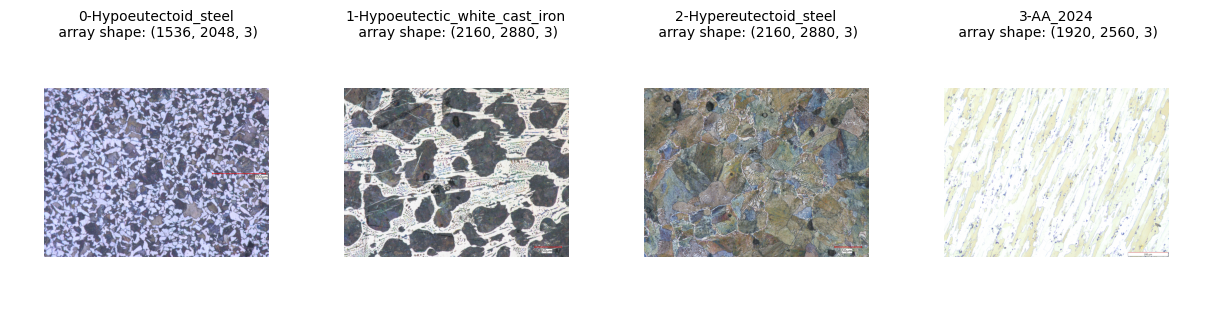

In [9]:
fig, axes = plt.subplots(1, len(LIST_SUB_DIR), layout="constrained")
fig.set_size_inches((12,3))

for subdir, axis in zip(LIST_SUB_DIR, axes):
    files = sorted(subdir.glob('*.jpg'))           # subdir.glob(*.jpg') -> all the *.jpg files in subdir
    imBGR = cv2.imread(files[0])                   # load the image file (BGR: Blue, Green, Red)
    imRGB = cv2.cvtColor(imBGR, cv2.COLOR_BGR2RGB) # convert image format from BGR to RGB
    
    # display images:
    axis.imshow(imRGB)
    axis.set_title(f'{subdir.name}\n array shape: {imRGB.shape}', fontsize=10) 
    axis.axis('off')
    axis.axis('equal')

## Check: size of the images

Let's look if the images have all the same size:

In [10]:
shapes = []

for subdir in LIST_SUB_DIR:
    files = sorted(subdir.glob('*.jpg'))      # '*.jpg' -> all the *.jpg files in 'subdir'
    print(f'collecting image size in subdir "{subdir.name}"')
    for file in files:
        img = cv2.imread(file)
        h, w, _ = img.shape
        shapes.append((w, h))
        
# set(shapes) gives a set where every element is uniq:        
print(f'Found image sizes: {set(shapes)}')

collecting image size in subdir "0-Hypoeutectoid_steel"
collecting image size in subdir "1-Hypoeutectic_white_cast_iron"
collecting image size in subdir "2-Hypereutectoid_steel"
collecting image size in subdir "3-AA_2024"
Found image sizes: {(2560, 1920), (2048, 1536), (2880, 2160)}


All the images have not the same size => we will have to resize the images to a common size.

# 2 - Preprocessing of the images

__Size__:<br>
- all the images must have the same size
- the size of the images should not be too large if we want acceptable computation times...

$\leadsto$ the micrographs available are high resolution images ( 2048$\times$1536 and 2880$\times$2160 ): we will lower the image size with the fucntion `resize` of the `openCV` module.

__RGB__  or __gray tones__:<br>
If the color information of the images is not relevant for their classification, we can gain calculation time and minimize the memory footprint by converting the images into gray tones.

$\leadsto$ As the color is not the main classification information for this dataset, we will convert the RGB images to gray-tone images with the `cvtColor` function of OpenCV.

In [11]:
w_target, h_target = 500, 400      # new image width and height

### Example:

Let's resize and convert in gray the first images of the three image sub-directories:

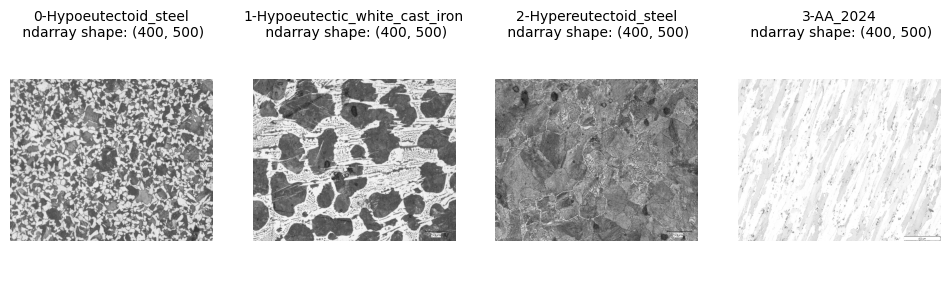

In [12]:
fig, axes = plt.subplots(1, len(LIST_SUB_DIR))
fig.set_size_inches((12,3))

for subdir, axis in zip(LIST_SUB_DIR, axes):
    files = sorted(subdir.glob('*.jpg'))              # *.jpg' means: all the *.jpg files in 'subdir'
    img = cv2.imread(files[0])                        # load the first image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)       # convert color image into grayscale image
    img = cv2.resize(img, dsize=(w_target, h_target)) # new size given as: (width, height)
    
    axis.imshow(img, cmap='gray')
    axis.set_title(f'{subdir.name}\n ndarray shape: {img.shape}', fontsize=10) 
    axis.axis('off')
    axis.axis('equal')

### Building the data set

Now:<br>
- we create the ndarray `images` of all the images resized and converted in gray tone<br>
- we build the corresponding `labels` ndarray.

In [13]:
# Initiallize empty lists:
images, labels = [], []
class_label, class_rank = [], []  # the list of the class labels & ranks

for rank, subdir in enumerate(LIST_SUB_DIR):

    label = subdir.name.split('-')[1]   # remove the '1-', '2-'.. from the subdir name
    class_label.append(label)
    class_rank.append(rank)
    
    print(f'Building dataset for class_rank:{rank}, class_label: "{label}" from subdir <{subdir.name}>')
    files = list(subdir.glob("*.jpg"))     # glob('*.jpg') -> all the *.jpg files in 'subdir'
    #files.sort()
    
    for f in files:
        print(f'\r\treading file {f.name}', end='')
        img = cv2.imread(f)                               # load the first image
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)        # convert color image into grayscale image
        img = cv2.resize(img, dsize=(w_target, h_target)) # new size given as: (width, height)

        # append data to the corresponding lists:
        images.append(img)
        labels.append(rank)
    print(f'\r\tdone{40*" "}')
    
# convert lists as ndarrays:    
images = np.array(images)
labels = np.array(labels)

Building dataset for class_rank:0, class_label: "Hypoeutectoid_steel" from subdir <0-Hypoeutectoid_steel>
	done                                        
Building dataset for class_rank:1, class_label: "Hypoeutectic_white_cast_iron" from subdir <1-Hypoeutectic_white_cast_iron>
	done                                        
Building dataset for class_rank:2, class_label: "Hypereutectoid_steel" from subdir <2-Hypereutectoid_steel>
	done                                        
Building dataset for class_rank:3, class_label: "AA_2024" from subdir <3-AA_2024>
	done                                        


In [14]:
class_label, list(class_rank)

(['Hypoeutectoid_steel',
  'Hypoeutectic_white_cast_iron',
  'Hypereutectoid_steel',
  'AA_2024'],
 [0, 1, 2, 3])

<span style="color:Blue; font-family:arial; font-size:11pt;">
    Print the total number of images:
</span>

In [15]:
len(images)

366

<span style="color:Blue; font-family:arial; font-size:11pt;">
    Check the size of the first and last images:
</span>

In [16]:
images[0].shape, images[-1].shape

((400, 500), (400, 500))

Summary:

In [17]:
print(f'{images.shape=}, {images.dtype=}')
print(f'{labels.shape=}, {labels.dtype=}')
print(f"total size of the {len(images)} images ndarray in memory: {images.size/1024/1024:.1f} MiB")

images.shape=(366, 400, 500), images.dtype=dtype('uint8')
labels.shape=(366,), labels.dtype=dtype('int64')
total size of the 366 images ndarray in memory: 69.8 MiB


# 3 - Prepare the _train_, _valid_ and _test_ data sets

### Split the full datset into train, valid & test datasets

Thanks to the `train_test_split` function of the `sklearn` module we can split the `images` and `labels` ndarrays into sub-datasets.<br>
Images and labels are randomly selected but respecting the proportion of each of the 3 classes in the original dataset (this is the interest of the `stratify` argument of the `train_test_split` function).

Following the state of the art in Deep Learning, we will split the full dataset into 3 sub-datasets:
- `train` for the training of the model
- `valid` for the validation during the model training
- `test` to evaluate the model score after training.

$\leadsto$ See the function `split_stratified_into_train_val_test` in the module `tools` from the `utils` directory.<br>

In [18]:
from utils.tools import split_stratified_into_train_val_test
train_dataset, valid_dataset, test_dataset = split_stratified_into_train_val_test((images, labels), 
                                                                                  frac_train=0.7, 
                                                                                  frac_val=0.1,
                                                                                  frac_test=0.2, 
                                                                                  seed=SEED)
# Extract image and label arrays from the datasets:
train_img, train_lab = train_dataset
valid_img, valid_lab = valid_dataset
test_img, test_lab   = test_dataset

### Define constants:

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are retrieved from the data set:
- with the shape attribute of the `train_img` and `test_img` arrays
- with the size attribute of the first training image for example


In [19]:
NB_TRAIN_IMG = train_img.shape[0] # number of training images
NB_VALID_IMG = valid_img.shape[0] # number of validation images 
NB_TEST_IMG  = test_img.shape[0]  # number of test images

NB_PIXEL     = train_img[0].size  # number of elements (pixels) of the firts training image: 

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")

NB_CLASS = len(set(train_lab))     # number of classes
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

256 training images, 36 validation images and 74 test images
400x500=200000 pixels in each image
4 classes found in the `train_lab` ndarray


### Check: display the shapes of the dataset arrays

Unbalanced classes can create some difficulties to train and evaluate the model: we verify that the proportion of digits remains homogenous in the 3 datasets thanks to the `plot_proportion_bar` of the `utils.tools` module:

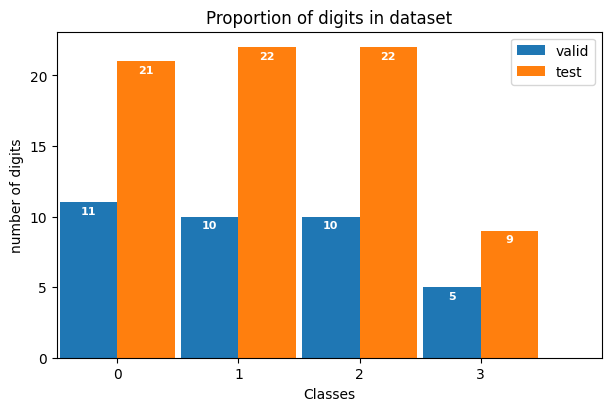

In [20]:
# build the dictionnary of the classes proportion in each dataset:
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(NB_CLASS)]  # list of # of 1, # of 2... in the vaild dataset
prop['test']  = [ (test_lab  == i).sum() for i in range(NB_CLASS)]  # list of # of 1, # of 2... in the test dataset
plot_proportion_bar(prop, range(NB_CLASS));

We can expect some difficulties to classify images of classe 0, du to the small number of images of this class...

### Check: display a train image randomy selected

After the pre-processing of the raw images to build the train dataset, it is advisable to check visualy the processed images:

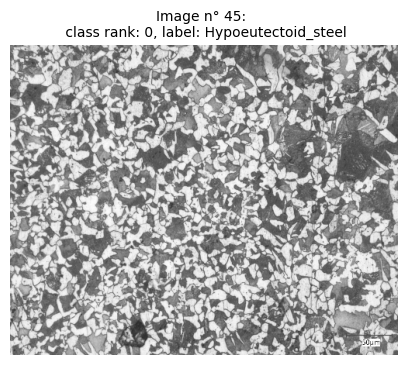

In [21]:
img_rank = np.random.randint(0, len(train_img))

plt.figure(figsize=(5, 5))
plt.imshow(train_img[img_rank], cmap='gray')
plt.title(f'Image n° {img_rank}: \n class rank: {train_lab[img_rank]}, label: {class_label[train_lab[img_rank]]}',
          fontsize=10)
plt.axis('off');

### Updating the dimensions of the input data for the _keras_ module:

The convolutional layers of the *kera*s module expect 4-dimensional arrays `(batch_size, height, width, depth)` by default:
- `batch_size`: number of input images in the batch,
- `height` and `width`: height and width of images (in pixels),
- `depth`: depth of the arrays (`3` for an RGB image, `1` for a grayscale image).

The shape of our images is:

In [22]:
train_img.shape, valid_img.shape, test_img.shape

((256, 400, 500), (36, 400, 500), (74, 400, 500))

It is therefore necessary to add a dimension (equal to `1`) after the third dimension `400`, for example with the `reshape` method of the `ndarray` arrays of numpy, without forgetting to divide the arrays by 255 to __normalize__ them:

In [23]:
# avec  la méthode reshape des tableaux ndarray de numpy :
x_train = train_img.reshape(train_img.shape + (1,))/255.
x_valid = valid_img.reshape(valid_img.shape + (1,))/255
x_test  = test_img.reshape(test_img.shape + (1,))/255

Check:

In [24]:
train_img.shape, x_train.shape, x_train.min(), x_train.max(),

((256, 400, 500), (256, 400, 500, 1), 0.0, 1.0)

In [25]:
test_img.shape, x_test.shape, x_test.min(), x_test.max()

((74, 400, 500), (74, 400, 500, 1), 0.0, 1.0)

### One-hot formatting of labels

The labels data must be given as an array of vectors _one-hot_ coding the integer value of the labels:

In [26]:
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

# 4 - Build the convolutional neural network

## 4.1 - The convolution operation

### Extracting features from an image with a convolution filter

The convolution of an image by a filter (also called *kernel*) consists of moving a _small 2D window_ (3x3, 5x5....) over the pixels of the image and calculating each time the _contracted tensor product_ between the elements of the filter and the pixels of the image delimited by the filter window (sum of the products term by term).<br>

The animation below illustrates the convolution of a 5x5 image by a 3x3 filter without *padding* on the edges: we obtain a new, smaller image of 3x3 pixels<br>
<p style="text-align:center; font-style:italic; font-size:12px;">
     <img src="img/filter_3x3.png" width="80" style="display:inline-block;">
     <img src="img/Convolution_schematic.gif" width="300" style="display:inline-block;"><br>
     [image credit: <a href="http://deeplearning.stanford.edu/tutorial">Stanford deep learning tutorial</A>]
</p>

### Padding

To maintain the size of the image, we can use a *padding* technique to create new data on the edges of the input image (by duplicating data on the edges, or adding rows and columns of 0... for example):

<p style="text-align:center; font-style:italic; font-size:12px;">
     <img src="img/padding.gif" width="350"><br>
     [image credit: <a href="https://medium.com/data-science/applied-deep-learning-part-4-convolutional-neural-networks-584bc134c1e2">Arden Dertat</a> ]
</p>

The goal of convolution is to extract features present in the source image: we speak of a “feature map” to designate the image produced by the convolution operation. The state of the art leads to using several convolutional filters to extract different characteristics: we can have up to several dozen convolutional filters in the same layer of the network which generate as many _feature maps_, hence the increase in data created by these convolution operations...

#### Examples of feature extraction with known convolutional filters ([Prewitt filter](https://fr.wikipedia.org/wiki/Filtre_de_Prewitt)):

As an example to understand the convolution operation, the figure below shows the *feature maps* obtained by convolving a MNIST image (a digit 7) with 4 "3x3" filters well known in image processing (Prewitt filters for contour extraction) :

<p style="text-align:center; font-style:italic; font-size:12px;">
     <img src="img/7_mnist_4_filtres.png" width="500"><br>
     [image credit: JLC]
</p>

We see that these filters act as *edge detection* filters: in the output images, the whitest pixels constitute what the filters detected:
- filters (a) and (c) detect lower and upper horizontal contours,
- filters (b) and (d) detect right and left vertical contours.

These very simple examples allow you to understand how the extraction of *features* from an image using convolutional filtering works.

#### From the convolutional filter to the convolutional neuron layer

The integration of convolutional filtering into the structure of the neural network gives the following organization of calculations:

- Each convolutional filter has the same coefficients for the 3 RGB image colors: for the LeNet5 network for example, each of the 6 "5x5x3" filters of the first layer has only 25 coefficients (5x5) identical for the 3 colors R, G & B.

- Each unit (convolutional neuron) of a *feature map* of layer C1 receives 75 pixels (25 red pixels $R_i$, 25 green pixels $G_i$ and 25 blue pixels $B_i$) delimited by the position of the convolutional filter in the source image.

- The neuron $k$ of a *feature map* calculates an output $y_k = F_a(\sum_{i=1}^{25}{\omega_i(R_i + G_i + B_i) - b_k})$, where $ b_k$ is the bias of the neuron $k$ and $F_a$ the activation function (very often `relu`).

- for the 6 convolutional filters of layer C1, we therefore have 6 x (25 + 1) parameters, i.e. 156 unknown parameters for this layer which will be determined by training the network.

The same pattern is used in all convolutional layers.

### Reducing the amount of information with _pooling_

*pooling* aims to reduce the amount of data to be processed. As for the convolution operation, we move a filter over the elements of the *feature map* array and at each position of the filter, we calculate a number representing all the elements selected in the filter (the maximum value, or the average....). But unlike convolution, we move the filter without overlap.<br>
In the simplified example below, the *max spool* filter transforms the 8x8 matrix into a 4x4 matrix which describes "roughly" the same information but with less data:
<p style="text-align:center; font-style:italic; font-size:12px;">
     <img src="img/max_pool_2x2.png" width="350"><br>
     [image credit: JLC]
</p>

## 4.2 - CNN inspired from the "LeNet5 CNN"  with tensorflow/keras    ([wiki](https://en.wikipedia.org/wiki/LeNet))

We build a convolutional NN similar to __LeNet5__ introduced in the research paper “Gradient-Based Learning Applied To Document Recognition” in 1998 by Yann LeCun, Leon Bottou, Yoshua Bengio, and Patrick Haffnerfrom.<br>
LeNet5 was originally designed for 32$\times$32 images:

<p style="text-align:center; font-style:italic; font-size:12px;">
     <img src="img/LeNet5.png"><br>
     [image credit: <a href="https://www.researchgate.net/publication/2985446_Gradient-Based_Learning_Applied_to_Document_Recognition">ReserchGate</a> ]
</p>

In [27]:
def build_DNN(dropout=0., seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential(name='LeNet5')
    model.add(Input(shape=x_train[0].shape))
    model.add(Conv2D(16, kernel_size=5, padding='valid', activation='relu', name='C1'))
    model.add(MaxPool2D(pool_size=2, name='S2'))
    model.add(Conv2D(32, kernel_size=5, padding='valid', activation='relu', name='C3'))
    model.add(MaxPool2D(pool_size=2, name='S4'))
    model.add(Conv2D(64, kernel_size=5, padding='valid', activation='relu', name='C5'))
    model.add(MaxPool2D(pool_size=2, name='S6'))
    model.add(Flatten())
    model.add(Dense(128, activation='relu', name='F6'))
    model.add(Dropout(dropout, seed=seed))                           
    model.add(Dense(NB_CLASS, activation='softmax', name='Output'))
    
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    if name: model.name = name
    return model
    

In [28]:
model = build_DNN()
model.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 396, 496, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2 (MaxPooling2D)               │ (None, 198, 248, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 194, 244, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4 (MaxPooling2D)               │ (None, 97, 122, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5 (Conv2D)                     │ (None, 93, 118, 64)    │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S6 (MaxPooling2D)               │ (None, 46, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 173696)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6 (Dense)                      │ (None, 128)            │    22,233,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,298,244 (85.06 MB)

 Trainable params: 22,298,244 (85.06 MB)

 Non-trainable params: 0 (0.00 B)

### Save the initial state of the network (structure & data)

We can save the weights of the initial untrained network (random values) and its structure with the `model.save` method. <br>
This will be useful later to re-create the network to its initial state if we want to compare dirrefent trainings:

In [29]:
DROPOUT = 0.2
model_init_name = f'CNN_seed-{SEED}_drop-{DROPOUT}'
model_init_file = f'{model_init_name}_init.keras'
model_init_path = model_dir / model_init_file

model = build_DNN(seed=SEED, dropout=DROPOUT)
model.save(model_init_path)

In [30]:
tree = scan_dir('model', tag='CNN', sortbydate=True)
for i, f in enumerate(tree): 
    print(f'[{i}]:', f)

[0]: model/CNN_seed-11_init.keras
[1]: model/CNN_seed-1234_init.keras
[2]: model/CNN_seed-1234_drop-0.4_init.keras
[3]: model/CNN_seed-1234_drop-0.3_init.keras
[4]: model/CNN_seed-1234_drop-0.1_init.keras
[5]: model/CNN_seed-1234_drop-0.2_init.keras


# 5 - Train the network <a name="5"></a>

We train the network with `EarlyStopp` to avoid overfit:

In [31]:
t0 = time()

#
# 1 - Define the 'callback' EarlyStopping in the callback list:
#
METRIC   = 'val_loss'
PATIENCE = 2

callbacks_list = [
    EarlyStopping(monitor=METRIC,      # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1) ]

# load the network structure & initial weights:
print(f'Loading model from <{model_init_path}>')
model = tf.keras.models.load_model(model_init_path)

#
# 2 - Deterministic tensorflow training: 
#
tf.keras.utils.set_random_seed(SEED)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

NB_EPOCH   = 25  # the max number of epochs...
BATCH_SIZE = 16

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=NB_EPOCH,      # the total number of successive trainings
                 batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)

print(elapsed_time_since(t0))

Loading model from <model/CNN_seed-1234_drop-0.2_init.keras>
Epoch 1/25


/home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.3008 - loss: 2.7707 - val_accuracy: 0.2778 - val_loss: 1.2718
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 460ms/step - accuracy: 0.2891 - loss: 1.2447 - val_accuracy: 0.4722 - val_loss: 1.2155
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 473ms/step - accuracy: 0.3477 - loss: 1.1495 - val_accuracy: 0.3611 - val_loss: 1.0492
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 452ms/step - accuracy: 0.4297 - loss: 1.0182 - val_accuracy: 0.6389 - val_loss: 1.0277
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 457ms/step - accuracy: 0.6875 - loss: 0.9583 - val_accuracy: 0.3889 - val_loss: 0.9353
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.6484 - loss: 0.8117 - val_accuracy: 0.5556 - val_loss: 0.8674
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 460ms/step - accuracy: 0.8477 - loss: 0.5413 - val_accuracy: 0.8611 - val_loss: 0.3471
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 457ms/step - accuracy: 0.9648 - loss: 0.1202 - val_accuracy: 0.9722 - val_

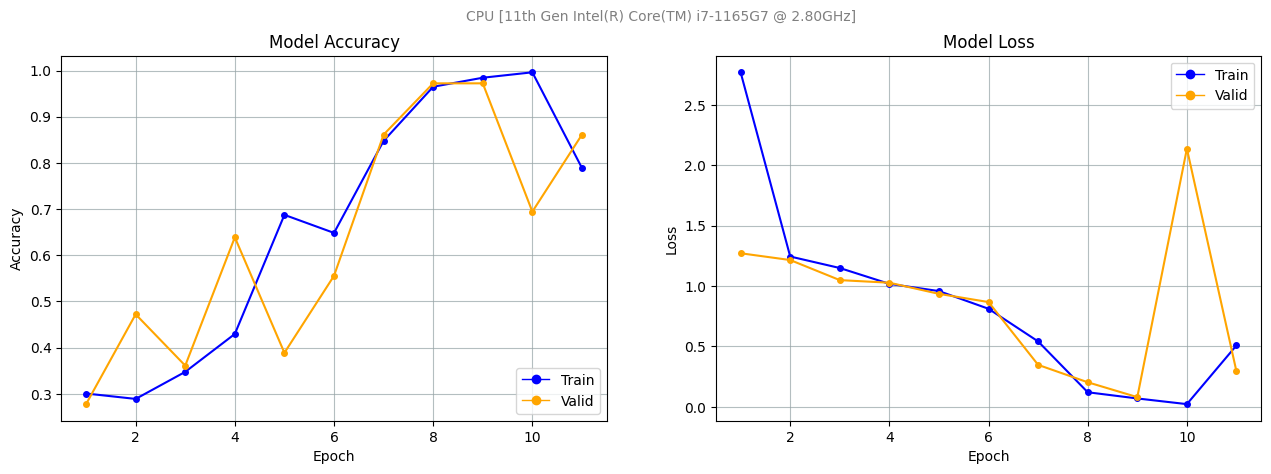

In [32]:
plot_loss_accuracy(hist)

# 6 - Evaluate the trained network <a name="6"></a>

## Show the confusion matrix

In [33]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Predicting labels for test images
predict_labels = np.argmax(model.predict(x_test), axis=-1)

# Display classification report
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=-1), predict_labels))

3/3 - 1s - 201ms/step - accuracy: 0.9865 - loss: 0.0777
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        22
           2       1.00      0.95      0.98        22
           3       0.90      1.00      0.95         9

    accuracy                           0.99        74
   macro avg       0.97      0.99      0.98        74
weighted avg       0.99      0.99      0.99        74



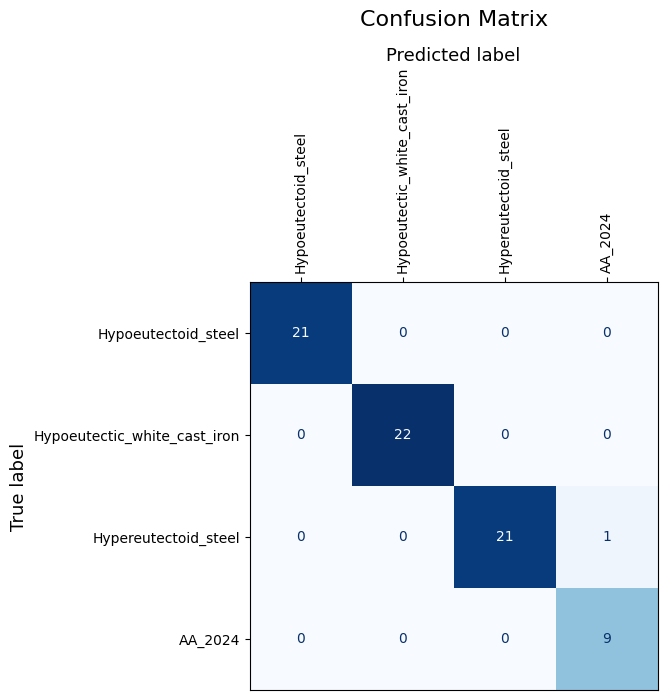

In [34]:
show_conf_matrix(test_lab, predict_labels, class_label, xticks_rot='vertical', figsize=(7,6));

# 7 - Data augmentation

The idea is to create news images by transfroming ariginal images of the dataset:
- flip left-right, up-down, rotate...
- modify contrast, luminosity...

The new images are added to the dataset to improve the trained model perfomance (avoid overfitting, increase accuracy...)

In [35]:
for i in range(len(LIST_SUB_DIR)):
    subdir = LIST_SUB_DIR[i]
    print (f'Subdir {subdir.name} has {len(list(subdir.glob('*.jpg')))} image')

Subdir 0-Hypoeutectoid_steel has 106 image
Subdir 1-Hypoeutectic_white_cast_iron has 107 image
Subdir 2-Hypereutectoid_steel has 107 image
Subdir 3-AA_2024 has 46 image


We will add around 60 augmented images to the `AA_2024` directory to build the new `aug_images` array:

1. Create the empty list `orig_img` 
2. Take one image out of 2 from the `3-AA_2024` directory (23 images):
    - read, resize to (400, 500) and convert (greyscale) the image
    - add the image to `orig_img`
3. Transform the list `orig_img` into a ndarray.

In [36]:
subdir =  LIST_SUB_DIR[3]
subdir

PosixPath('../Data/3-AA_2024')

In [37]:
orig_img = []

files = list(subdir.glob("*.jpg"))     # glob('*.jpg') -> all the *.jpg files in 'subdir'
for f in files[::2]:
    img = cv2.imread(f)                               # load the first image
    img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)        # convert color image into grayscale image
    img = cv2.resize(img, dsize=(w_target, h_target)) # new size given as: (width, height)
    orig_img.append(img)
        
orig_img = np.array(orig_img)

Verify the number & size of the original images taken from the `3-AA_2024` directory (should be 23 images):

In [38]:
orig_img.shape

(23, 400, 500)

Use the [flip_left_right](https://www.tensorflow.org/api_docs/python/tf/image/flip_left_right) and 
[flip_up_down](https://www.tensorflow.org/api_docs/python/tf/image/flip_up_down) functions of **tensorflow.image** to transform `orig_img` into `flip_LR` and `flip_UD` ndarrays:

In [39]:
from tensorflow.image import flip_left_right, rot90, flip_up_down, rgb_to_grayscale

In [40]:
flip_LR = flip_left_right(orig_img)
flip_UD = flip_up_down(orig_img)

Check the shape of `flip_LR` and `flip_UD`:

In [41]:
flip_LR.shape, flip_UD.shape

(TensorShape([23, 400, 500]), TensorShape([23, 400, 500]))

With the [np.concatenate](https://numpy.org/doc/1.26/reference/generated/numpy.concatenate.html) function of *numpy*, 
define `aug_images`, the concatenation of `images` with `flip_LR.numpy()` and `flip_UD.numpy()`, using axis 0<br>
Check the new shape of `images`.

In [42]:
aug_images = np.concatenate((images, flip_LR.numpy(), flip_UD.numpy()), axis=0)

In [42]:
aug_images = np.concatenate((images, flip_LR.numpy()), axis=0)

In [43]:
aug_images.shape

(389, 400, 500)

Define `new_labels`, the ndarray of labels (`uint8`) corresponding to the images added to `images`.<br>
Display `new_labels`.

In [44]:
new_labels = np.ndarray(orig_img.shape[0], dtype='uint8')
new_labels.fill(3)
new_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3], dtype=uint8)

Define `aug_labels`, the concatenation of  `labels` and `new_labels`, using axis 0<br>
Check the new shape of `aug_images`.

In [45]:
aug_labels = np.concatenate((labels, new_labels), axis=0)
aug_labels.shape

(389,)

Now, you can copy/paste/modify cells from sections 3 5 & 6 to prepare the new datasets, train and evaluate the model with these new dataset:

In [46]:
from utils.tools import split_stratified_into_train_val_test
train_dataset, valid_dataset, test_dataset = split_stratified_into_train_val_test((aug_images, aug_labels), 
                                                                                  frac_train=0.7, 
                                                                                  frac_val=0.1,
                                                                                  frac_test=0.2, 
                                                                                  seed=SEED)
# Extract image and label arrays from the datasets:
train_img, train_lab = train_dataset
valid_img, valid_lab = valid_dataset
test_img, test_lab   = test_dataset

In [47]:
NB_TRAIN_IMG = train_img.shape[0] # number of training images
NB_VALID_IMG = valid_img.shape[0] # number of validation images 
NB_TEST_IMG  = test_img.shape[0]  # number of test images

NB_PIXEL     = train_img[0].size  # number of elements (pixels) of the firts training image: 

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")

NB_CLASS = len(set(train_lab))     # number of classes
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

272 training images, 39 validation images and 78 test images
400x500=200000 pixels in each image
4 classes found in the `train_lab` ndarray


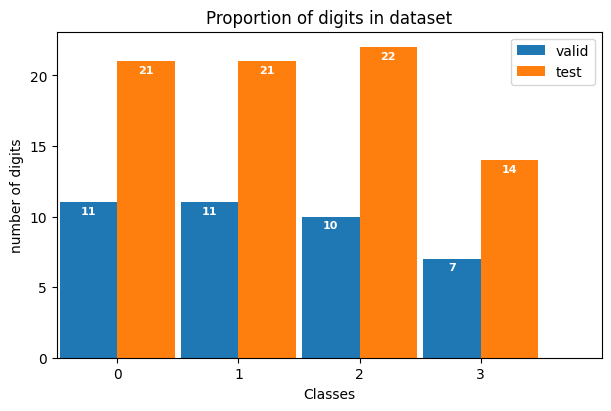

In [48]:
# build the dictionnary of the classes proportion in each dataset:
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(NB_CLASS)]  # list of # of 1, # of 2... in the vaild dataset
prop['test']  = [ (test_lab  == i).sum() for i in range(NB_CLASS)]  # list of # of 1, # of 2... in the test dataset
plot_proportion_bar(prop, range(NB_CLASS));

In [49]:
# avec  la méthode reshape des tableaux ndarray de numpy :
x_train = train_img.reshape(train_img.shape + (1,))/255.
x_valid = valid_img.reshape(valid_img.shape + (1,))/255
x_test  = test_img.reshape(test_img.shape + (1,))/255

In [50]:
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

In [51]:
t0 = time()

#
# 1 - Define the 'callback' EarlyStopping in the callback list:
#
METRIC   = 'val_loss'
PATIENCE = 2

callbacks_list = [
    EarlyStopping(monitor=METRIC,      # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1) ]

# load the network structure & initial weights:
print(f'Loading model from <{model_init_path}>')
model = tf.keras.models.load_model(model_init_path)

#
# 2 - Deterministic tensorflow training: 
#
tf.keras.utils.set_random_seed(SEED)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

NB_EPOCH   = 25  # the max number of epochs...
BATCH_SIZE = 16

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=NB_EPOCH,      # the total number of successive trainings
                 batch_size=BATCH_SIZE, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)

print(elapsed_time_since(t0))

Loading model from <model/CNN_seed-1234_drop-0.2_init.keras>
Epoch 1/25


/home/jlc/work/IA-MachineLearning/18-DIADEM/DIADEM_DL/Classification/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 467ms/step - accuracy: 0.2868 - loss: 2.8692 - val_accuracy: 0.2308 - val_loss: 1.2047
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 452ms/step - accuracy: 0.4632 - loss: 1.0517 - val_accuracy: 0.3077 - val_loss: 0.9731
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.4779 - loss: 0.9113 - val_accuracy: 0.8205 - val_loss: 0.7595
Epoch 4/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 459ms/step - accuracy: 0.7941 - loss: 0.5981 - val_accuracy: 0.8718 - val_loss: 0.3966
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 456ms/step - accuracy: 0.7868 - loss: 0.4763 - val_accuracy: 0.8462 - val_loss: 0.4267
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 453ms/step - accuracy: 0.9596 - loss: 0.1996 - val_accuracy: 1.0000 - val_loss: 0.0963
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 457ms/step - accuracy: 0.9522 - loss: 0.1111 - val_accuracy: 1.0000 - val_loss: 0.0620
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - accuracy: 0.8787 - loss: 0.2661 - val_accuracy: 0.9231 - val_

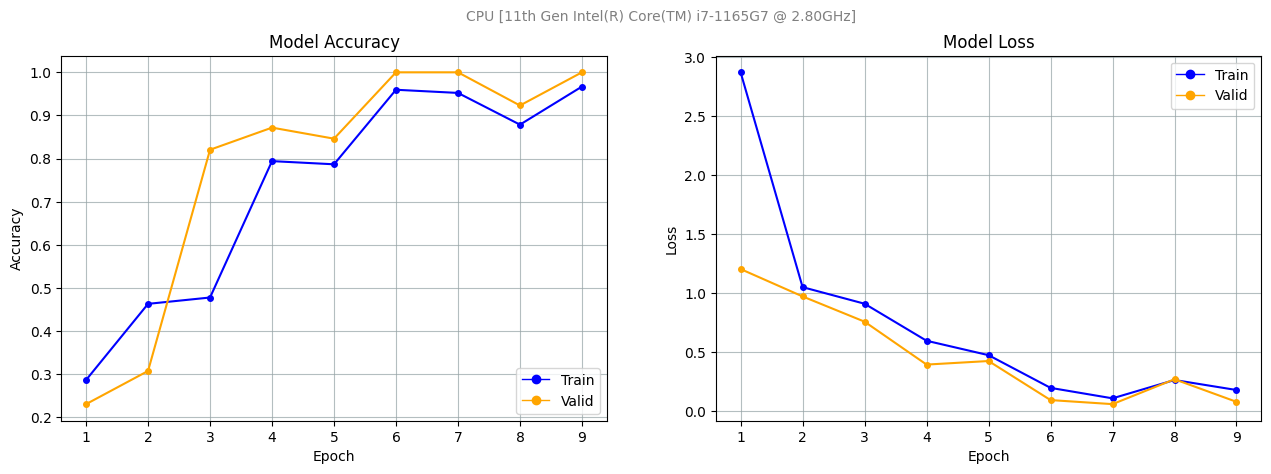

In [52]:
plot_loss_accuracy(hist)

In [53]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Predicting labels for test images
predict_labels = np.argmax(model.predict(x_test), axis=-1)

# Display classification report
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=-1), predict_labels))

3/3 - 1s - 210ms/step - accuracy: 1.0000 - loss: 0.0712
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        14

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



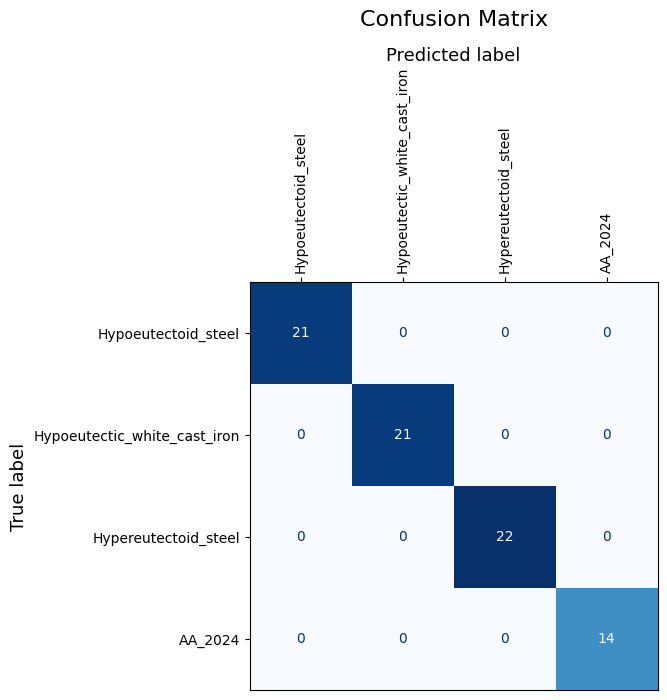

In [54]:
show_conf_matrix(test_lab, predict_labels, class_label, xticks_rot='vertical', figsize=(7,6));